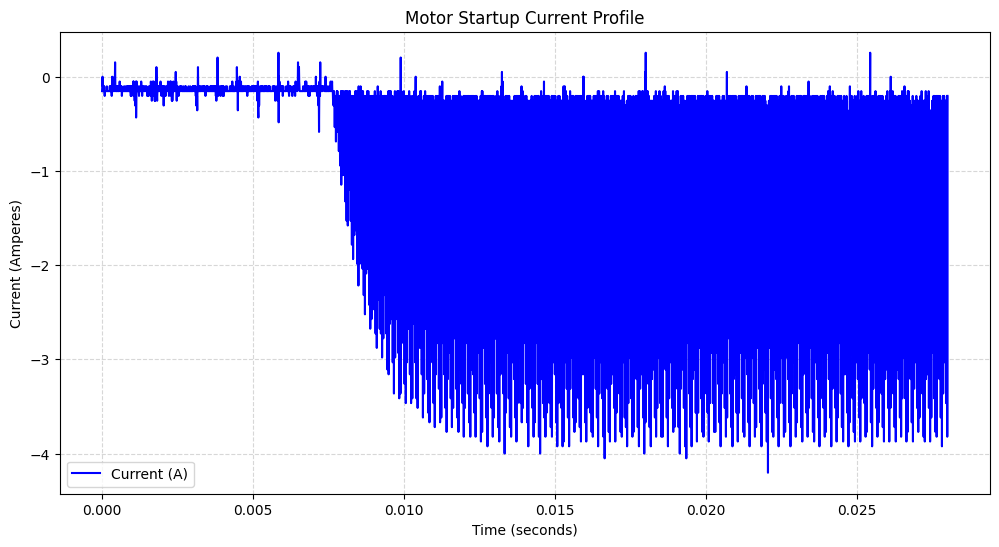

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_startup_current(file_path, r_shunt=1.57, probe_atten=10.0):
    # Read the CSV - skipping metadata by selecting specific columns
    # Adjust column indices if your scope uses a different layout
    df = pd.read_csv(file_path, header=None)
    
    # Extract time and voltage (Columns 3 and 4 in your snippet)
    time = pd.to_numeric(df[3][1:], errors='coerce')
    voltage_raw = pd.to_numeric(df[4][1:], errors='coerce')
    
    # Drop rows where we have metadata instead of numbers
    mask = time.notna() & voltage_raw.notna()
    time = time[mask].reset_index(drop=True)
    voltage_raw = voltage_raw[mask].reset_index(drop=True)
    
    # SCALING:
    # If the scope says 'Probe Atten 10.0', it usually means the recorded 
    # 'Value' needs to be multiplied by 10 if the scope didn't auto-scale.
    # Looking at your -0.024V reading, multiplying by 10 gives -0.24V.
    voltage_actual = voltage_raw * probe_atten
    current = voltage_actual / r_shunt
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(time, current, label='Current (A)', color='blue')
    
    # Calculate Power if V_out is 12V
    power = current * 12.0
    # plt.plot(time, power, label='Power (W)', color='red', alpha=0.5)
    
    plt.title('Motor Startup Current Profile')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Current (Amperes)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Run it
plot_startup_current('measurement data\\Scope_P14Pro_Startup_Current_1r57_shunt.csv')

<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\harri\AppData\Local\Temp\ipykernel_40624\3680774923.py:5: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  df = pd.read_csv('measurement data\Scope_P14Pro_Startup_Current_1r57_shunt.csv', header=None)


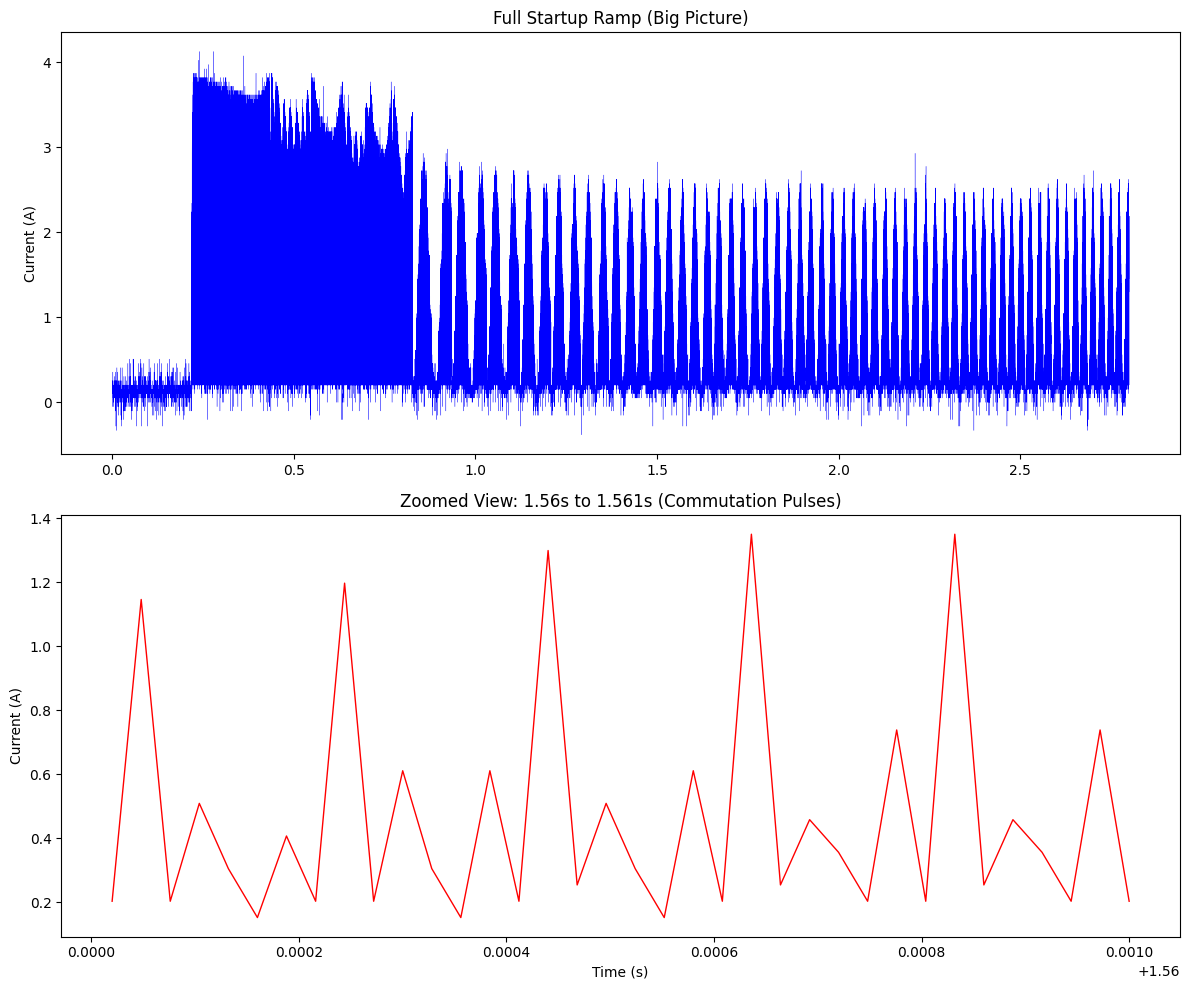

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (using the 'r' string fix)
#df = pd.read_csv('measurement data\Scope_P14Pro_Startup_Current_1r57_shunt.csv', header=None)
df = pd.read_parquet('motor_startup.parquet')
time = pd.to_numeric(df[3][1:], errors='coerce')
voltage = pd.to_numeric(df[4][1:], errors='coerce')
mask = time.notna() & voltage.notna()
t, v = time[mask].values, voltage[mask].values

# Adjust these based on your actual circuit
r_shunt = -1.57 
probe_atten = 10.0
current = (v * probe_atten) / r_shunt

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: The Full 12-Second Ramp
ax1.plot(t, current, color='blue', linewidth=0.2)
ax1.set_title('Full Startup Ramp (Big Picture)')
ax1.set_ylabel('Current (A)')

# Plot 2: The "Microscopic" Commutation Zoom
# Let's look at 100ms of data around the 10-second mark
zoom_start = 1.56
zoom_end = 1.561

mask_zoom = (t >= zoom_start) & (t <= zoom_end)
ax2.plot(t[mask_zoom], current[mask_zoom], color='red', linewidth=1)
ax2.set_title(f'Zoomed View: {zoom_start}s to {zoom_end}s (Commutation Pulses)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Current (A)')

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d

# --- 1. Load and Clean Data ---
#df = pd.read_csv(r'measurement data\Scope_P14Pro_Startup_Current_1r57_shunt.csv', header=None)
df = pd.read_parquet('motor_startup.parquet')

# Extract raw columns
raw_t = pd.to_numeric(df[3][1:], errors='coerce')
raw_v = pd.to_numeric(df[4][1:], errors='coerce')

# Drop NaNs
mask = raw_t.notna() & raw_v.notna()
t_raw = raw_t[mask].values
v_raw = raw_v[mask].values

# Convert to Current (Using positive shunt and probe attenuation)
r_shunt = -1.57 
probe_atten = 10.0
i_load_raw = (v_raw * probe_atten) / r_shunt

# --- 2. Fix Non-Equal Spacing (Resampling) ---
# Create a perfectly uniform time grid from the start to end of your data
t_uniform = np.linspace(t_raw.min(), t_raw.max(), len(t_raw))

# Interpolate the raw current onto the uniform grid
f_interp = interp1d(t_raw, i_load_raw, kind='linear', fill_value="extrapolate")
i_load = f_interp(t_uniform)

# --- 3. Define the System (40 Hz Bandwidth) ---
f_bw = 40.0
w_bw = 2 * np.pi * f_bw
# The response of the input source to a load change
sys_input_response = signal.TransferFunction([w_bw], [1, w_bw])

# --- 4. Simulate the Input Power ---
p_load = i_load * 12.0 # Power at the 12V rail
# Use the uniform time vector 't_uniform'
t_sim, p_input, _ = signal.lsim(sys_input_response, U=p_load, T=t_uniform)

# --- 5. Visualize the Result ---
plt.figure(figsize=(12, 7))
plt.plot(t_uniform, p_load, label='Actual Motor Load (W)', alpha=0.3, color='red', linewidth=0.5)
plt.plot(t_sim, p_input, label=f'Source Input Power (Smooth {f_bw}Hz)', linewidth=2, color='blue')
plt.axhline(65, color='black', linestyle='--', label='65W Source Limit', linewidth=2)

plt.title(f'Power Buffering Analysis: {f_bw}Hz Controller vs 65W Limit')
plt.ylabel('Power (Watts)')
plt.xlabel('Time (s)')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper right')

# Optional: Zoom into the middle of the ramp to see the "fuzz" vs the "smooth" line
# plt.xlim([5.0, 5.2]) 

plt.show()

KeyError: 3

Total C_out ESR: 36.68 mOhm


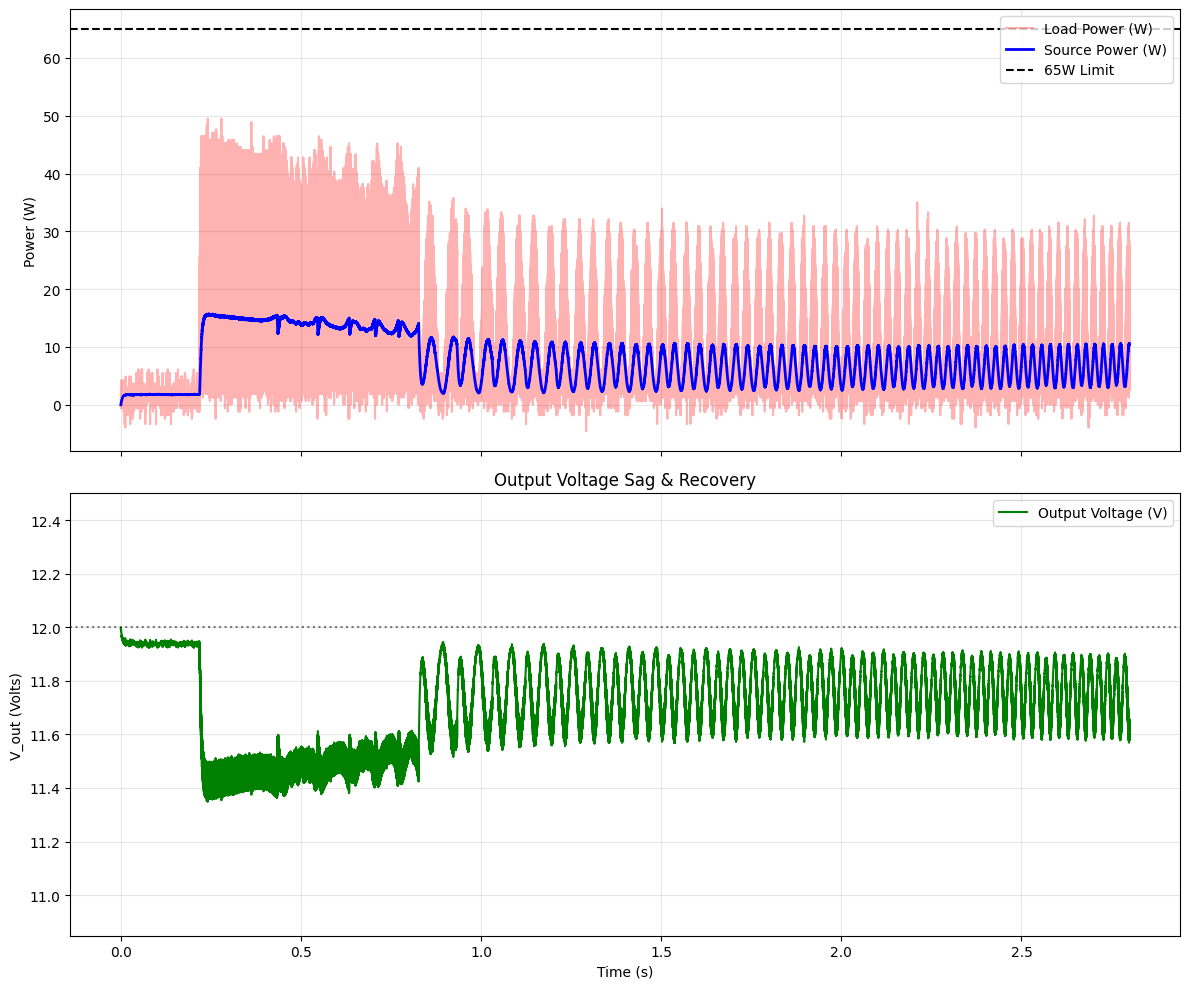

In [38]:
# --- Continuing from the previous script ---

# ESR Calculation from your provided formula
c_out = 9.4e-3
df_cap = 0.16 + 0.02 * 5
f_df = 120
r_esr = df_cap / (2 * np.pi * f_df * c_out)
print(f"Total C_out ESR: {r_esr*1000:.2f} mOhm")

# --- 1. Define Output Voltage Response ---
# The output voltage deviation (V_out - 12V) is driven by i_load
# through the Output Impedance of the closed-loop system.
# Simplified Z_out(s) = (1/sC_out + R_esr) || (Controller Response)

# For a simplified view, we look at the deviation:
# dV = (I_load / C_out) integrated - (Controller correction) + (I_load * R_esr)

# Define the controller's inability to reject load at high freq
# At high freq, the cap handles it; at low freq, the controller fixes it.
num_z = [r_esr * c_out, 1]
den_z = [c_out, w_bw * c_out] # w_bw from the 40Hz calculation
sys_v_response = signal.TransferFunction(num_z, den_z)

# --- 2. Simulate Voltage Deviation ---
# We simulate how i_load (U) creates a voltage drop (dV)
t_v, v_deviation, _ = signal.lsim(sys_v_response, U=i_load, T=t_uniform)

# Final V_out is nominal 12V minus the deviation
v_final = 12.0 - v_deviation

# --- 3. Plotting Results ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top Plot: Current & Power (Source vs Load)
ax1.plot(t_uniform, i_load * 12.0, label='Load Power (W)', alpha=0.3, color='red')
ax1.plot(t_sim, p_input, label='Source Power (W)', color='blue', linewidth=2)
ax1.axhline(65, color='black', linestyle='--', label='65W Limit')
ax1.set_ylabel('Power (W)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom Plot: Output Voltage
ax2.plot(t_uniform, v_final, color='green', label='Output Voltage (V)')
ax2.axhline(12, color='black', linestyle=':', alpha=0.5)
ax2.set_ylabel('V_out (Volts)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Voltage Sag & Recovery')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Set Y-axis to see the sag clearly (e.g., 8V to 13V)
ax2.set_ylim([v_final.min() - 0.5, 12.5])

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import glob
import os

# 1. Get a list of all your CSV parts
path = r'measurement data\slices' # Folder where you saved the parts
all_files = sorted(glob.glob(os.path.join(path, "*.csv")))

li = []

for filename in all_files:
    # Read each file, skipping metadata (Micsig usually has ~10-15 rows)
    # We identify metadata by looking for the first row that is all numbers
    df = pd.read_csv(filename, header=None)
    
    # Extract the data columns (usually 3 and 4)
    # Filter for rows where column 3 is actually a number
    df_clean = df[pd.to_numeric(df[3], errors='coerce').notnull()].copy()
    df_clean[3] = pd.to_numeric(df_clean[3])
    df_clean[4] = pd.to_numeric(df_clean[4])
    
    li.append(df_clean[[3, 4]])

# 2. Combine them
df_total = pd.concat(li, axis=0, ignore_index=True)
df_total.columns = ['Time', 'Voltage']

# 3. Fix the "Jump" (If the scope reset time to 0 for each slice)
# We calculate the time difference and shift each slice to follow the previous one
# This only works if your slices don't overlap or have gaps
# (Optional: If Micsig saved absolute time, you don't even need this)
# Save to the main folder
#df_total.to_csv('cleaned_motor_startup.csv', index=False)
#df_total.to_pickle('motor_startup.pkl')
# You might need to install it first: %pip install pyarrow
df_total.to_parquet('motor_startup.parquet')

In [ ]:
import pandas as pd
df = pd.read_parquet('motor_startup.parquet')

   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/28.2 MB 12.4 MB/s eta 0:00:03
   --------- ------------------------------ 6.8/28.2 MB 23.5 MB/s eta 0:00:01
   ------------------ --------------------- 13.1/28.2 MB 26.7 MB/s eta 0:00:01
   -------------------------- ------------- 18.9/28.2 MB 27.4 MB/s eta 0:00:01
   ----------------------------------- ---- 25.2/28.2 MB 28.1 MB/s eta 0:00:01
   ---------------------------------------  28.0/28.2 MB 27.4 MB/s eta 0:00:01
   ---------------------------------------  28.0/28.2 MB 27.4 MB/s eta 0:00:01
   ---------------------------------------- 28.2/28.2 MB 19.4 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
